<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/ball_and_hoop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ball and Hoop

This notebook loads and plots data for the ball and hoop case study. Data is available from the github repo.

## Quick description

This experiment utilizes the "CE109 - Ball & Hoop" bench. The primary objective of this system is to control the position of a ball along a hoop by adjusting its speed and angle so the ball remains in or reaches a desired position.

The system works by using a DC motor coupled to the hoop. A voltage signal between -10V and +10V is sent to the motor to adjust the hoop's speed and angle. When voltage is applied, the hoop rotates (positive voltages cause rotation in one direction and negative voltages in the reverse) and due to gravity, the ball begins to roll. The system monitors the ball's position, as well as the hoop's speed and angular position, through sensors that provide the following analog signals:
* Signal for hoop angular position: $\theta$
* Signal for hoop angular velocity: $\omega$
* Signal for ball angular position: $\Psi$

For this specific practice, the objective is to perform closed-loop control of the hoop's rotation speed. A controller receives sensor data and adjusts the voltage sent to the motor to correct the error between the measured speed and a user-defined target speed. This allows for applying control algorithms to automatically adjust the motor's voltage, between [-10, +10] V, to control the hoop's speed via feedback.

The imabe below shows the CE-109 Bench with labeled signals. The left side shows outputs for hoop angular position ($\theta$), hoop angular velocity ($\omega$), and ball angular position ($\Psi$). The right side shows inputs for the DC motor PWM signal (-10V to +10V) and a reference signal.

![CE-109 Bench to be used in the experiment.](https://www.tecquipment.com/assets/img/products/_700x504_fit_center-center_none/5913914/CE109.webp)

source: https://www.tecquipment.com/ball-and-hoop-apparatus


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import readData


In [2]:
def plot_io(time, u, y, yref=None, title=""):
    """Plot input u (top) and output y with optional reference yref (bottom)."""
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axs[0].plot(time, u, color='b')
    axs[0].set_ylabel('u (input)')
    if title:
        axs[0].set_title(title)
    axs[0].grid(True)
    axs[1].plot(time, y, 'k', label='y (output)')
    if yref is not None and len(yref) > 0:
        axs[1].plot(time, yref, 'r', label='yref (reference)')
    axs[1].set_ylabel('y (output)')
    axs[1].set_xlabel('time')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()


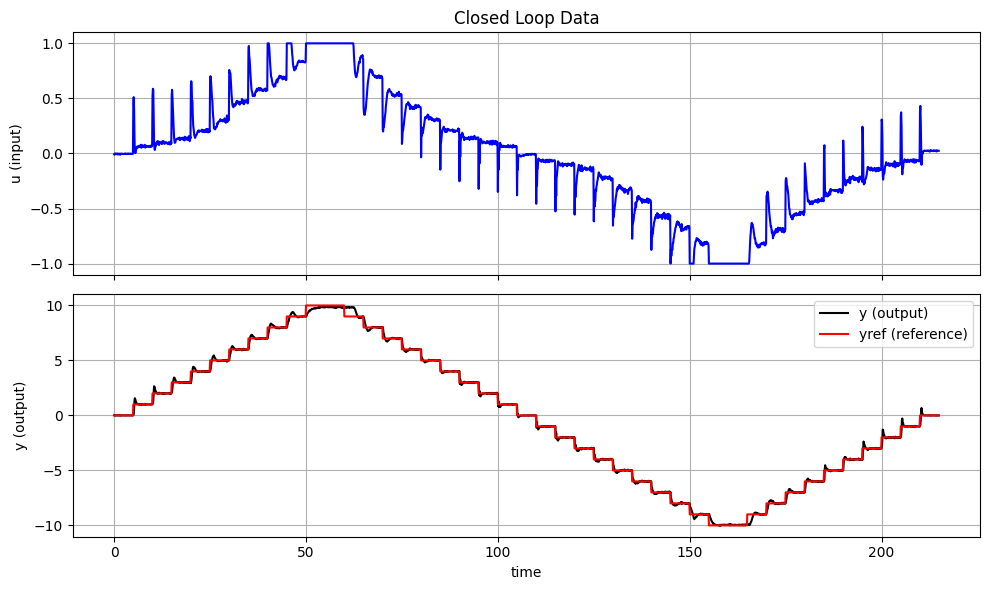

In [3]:
# Closed-loop dataset (includes the reference yref)
y, u, time, yref = readData("ball_and_hoop", "closedLoop", return_ref=True)
plot_io(time, u, y, yref, title="Closed Loop Data")


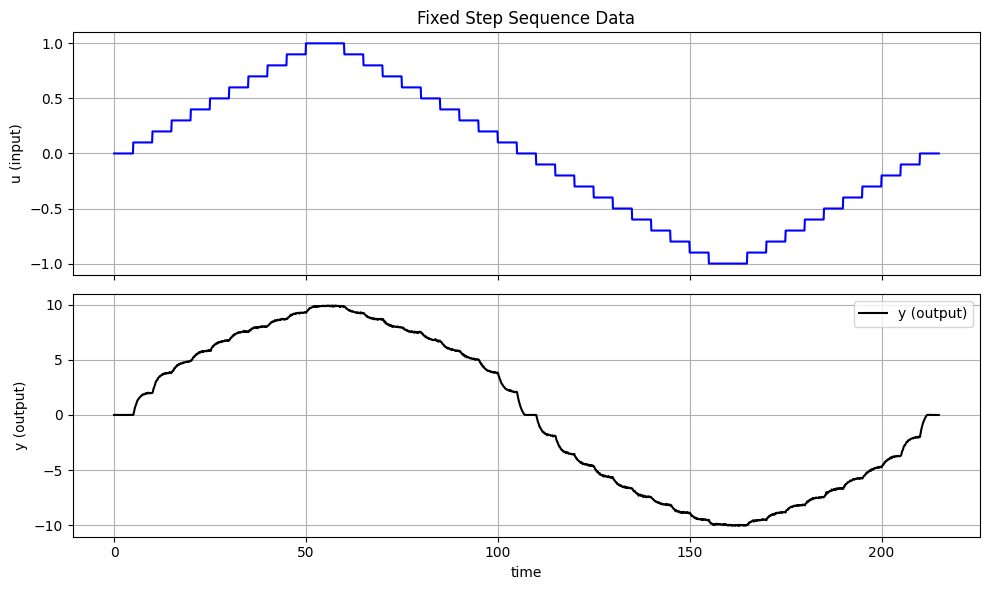

In [4]:
# Fixed step sequence dataset
y, u, time = readData("ball_and_hoop", "fixedStepSequence")
plot_io(time, u, y, title="Fixed Step Sequence Data")


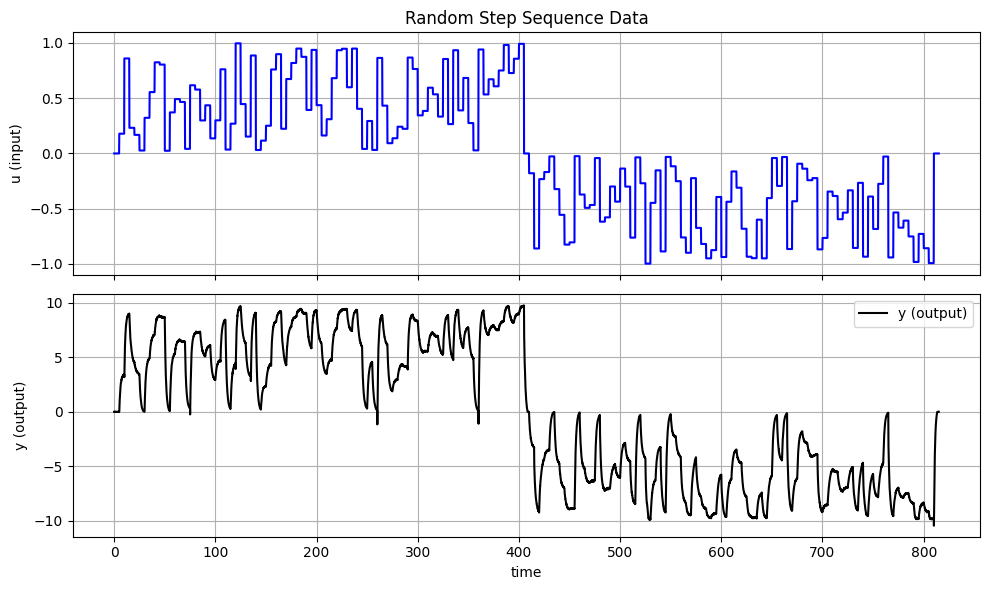

In [5]:
# Random step sequence dataset
y, u, time = readData("ball_and_hoop", "randomStepSequence")
plot_io(time, u, y, title="Random Step Sequence Data")
